# ECG Exploratory Data Analysis (EDA)

This notebook focuses on **signal quality assessment, filtering, heart rate analysis, and advanced ECG feature extraction**.

## Content:
1. Setup & Libraries
2. Load Data
3. Signal Quality Checks (Baseline, Powerline, Noise)
4. Filtering Demonstration (Baseline Removal, Notch, Bandpass)
5. R-peak Detection & RR/HR Analysis
6. Heart Rate Variability (HRV) Metrics
7. STL Decomposition of HR
8. Abnormality Detection
9. Label Distribution Statistics

## 1. Setup & Libraries

In [1]:
# Import thư viện cần thiết
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, welch, find_peaks, medfilt
from statsmodels.tsa.seasonal import STL
from collections import Counter

## 2. Load Data

In [2]:
# Danh sách record MIT-BIH
records = [
    "100", "101", "102", "103", "104", "105", "106", "107", "108", "109",
    "111", "112", "113", "114", "115", "116", "117", "118", "119",
    "121", "122", "123", "124",
    "200", "201", "202", "203", "205", "207", "208", "209",
    "210", "212", "213", "214", "215", "217", "219", "220",
    "221", "222", "223", "228", "230", "231", "232", "233", "234"
]

records_1xx = [r for r in records if r.startswith("1")]
records_2xx = [r for r in records if r.startswith("2")]

print("Total records:", len(records))

Total records: 48


In [3]:
# Load các record 1xx
ecg_data = {}

for rec in records_1xx:
    try:
        record = wfdb.rdrecord(rec, pn_dir='mitdb')
        ann = wfdb.rdann(rec, 'atr', pn_dir='mitdb')

        ecg_data[rec] = {
            "signal": record.p_signal[:, 0],  # MLII
            "fs": record.fs,
            "r_peaks": ann.sample,
            "labels": ann.symbol
        }

        print(f"Loaded record {rec}")

    except Exception as e:
        print(f"Failed to load record {rec}: {e}")

Loaded record 100
Loaded record 101
Loaded record 102
Loaded record 103
Loaded record 104
Loaded record 105
Loaded record 106
Loaded record 107
Loaded record 108
Loaded record 109
Loaded record 111
Loaded record 112
Loaded record 113
Loaded record 114
Loaded record 115
Loaded record 116
Loaded record 117
Loaded record 118
Loaded record 119
Loaded record 121
Loaded record 122
Loaded record 123
Loaded record 124


## 3. Signal Quality Checks (Baseline, Powerline, Noise)

In [4]:
# Hàm filter helpers
def butter_filter(x, fs, low=None, high=None, order=4):
    """Butterworth filter: bandpass/highpass/lowpass"""
    nyq = fs / 2
    if low is None and high is None:
        return x
    if low is not None and high is not None:
        btype = "band"
        Wn = [low/nyq, high/nyq]
    elif low is not None:
        btype = "high"
        Wn = low/nyq
    else:
        btype = "low"
        Wn = high/nyq
    b, a = butter(order, Wn, btype=btype)
    return filtfilt(b, a, x)

def estimate_baseline(ecg, fs, cutoff=0.5):
    """Ước lượng baseline wander (<0.5 Hz)"""
    return butter_filter(ecg, fs, high=cutoff, order=2)

In [5]:
# Hàm tính Signal Quality metrics
def psd_band_power(f, pxx, f1, f2):
    """Tính power trong band tần số [f1, f2]"""
    m = (f >= f1) & (f <= f2)
    if not np.any(m):
        return 0.0
    return float(np.trapz(pxx[m], f[m]))

def qc_signal_metrics(ecg, fs):
    """Tính signal quality metrics: baseline, powerline, noise"""
    baseline = estimate_baseline(ecg, fs, cutoff=0.5)
    baseline_std = float(np.std(baseline))
    baseline_ptp = float(np.ptp(baseline))

    # PSD analysis
    f, pxx = welch(ecg, fs=fs, nperseg=min(len(ecg), 4096))

    p_0_40 = psd_band_power(f, pxx, 0.0, 40.0) + 1e-12
    p_49_51 = psd_band_power(f, pxx, 49.0, 51.0)
    p_59_61 = psd_band_power(f, pxx, 59.0, 61.0)
    p_20_40 = psd_band_power(f, pxx, 20.0, 40.0)

    powerline_50_ratio = float(p_49_51 / p_0_40)
    powerline_60_ratio = float(p_59_61 / p_0_40)
    hf_noise_ratio_20_40 = float(p_20_40 / p_0_40)

    # Amplitude stats
    amp_std = float(np.std(ecg))
    amp_min = float(np.min(ecg))
    amp_max = float(np.max(ecg))

    return {
        "baseline_std": baseline_std,
        "baseline_ptp": baseline_ptp,
        "powerline_50_ratio": powerline_50_ratio,
        "powerline_60_ratio": powerline_60_ratio,
        "hf_noise_ratio_20_40": hf_noise_ratio_20_40,
        "amp_std": amp_std,
        "amp_min": amp_min,
        "amp_max": amp_max,
        "baseline_series": baseline,
        "psd_f": f,
        "psd_pxx": pxx
    }

In [6]:
# Hàm tính RR quality metrics
def compute_rr(r_peaks, fs):
    """Tính RR intervals (seconds)"""
    r_peaks = np.array(r_peaks, dtype=int)
    if len(r_peaks) < 2:
        return np.array([], dtype=float)
    return np.diff(r_peaks) / fs

def qc_rr_metrics(r_peaks, fs, rr_min=0.3, rr_max=2.5):
    """Tính RR quality metrics: check outliers"""
    rr = compute_rr(r_peaks, fs)
    if len(rr) == 0:
        return {"rr_min": None, "rr_max": None, "bad_rr_pct": None, "bad_rr_idx": [], "rr": rr}

    bad = (rr < rr_min) | (rr > rr_max)
    bad_idx = np.where(bad)[0].tolist()

    return {
        "rr_min": float(np.min(rr)),
        "rr_max": float(np.max(rr)),
        "bad_rr_pct": float(100.0 * np.mean(bad)),
        "bad_rr_idx": bad_idx,
        "rr": rr
    }

In [7]:
# Demo: Signal Quality Check cho record 101
rec_id = "101"
seconds_plot = 10

ecg_raw = ecg_data[rec_id]["signal"]
fs = ecg_data[rec_id]["fs"]
r_peaks = np.asarray(ecg_data[rec_id]["r_peaks"], dtype=int)

sig_qc = qc_signal_metrics(ecg_raw, fs)
rr_qc  = qc_rr_metrics(r_peaks, fs)

qc_output = {
    "record_id": rec_id,
    "fs_hz": fs,
    "duration_s": len(ecg_raw)/fs,
    "num_beats": len(r_peaks),
    "baseline_std": sig_qc["baseline_std"],
    "baseline_ptp": sig_qc["baseline_ptp"],
    "powerline_50_ratio": sig_qc["powerline_50_ratio"],
    "powerline_60_ratio": sig_qc["powerline_60_ratio"],
    "hf_noise_ratio_20_40": sig_qc["hf_noise_ratio_20_40"],
    "amp_std": sig_qc["amp_std"],
    "amp_min": sig_qc["amp_min"],
    "amp_max": sig_qc["amp_max"],
    "rr_min": rr_qc["rr_min"],
    "rr_max": rr_qc["rr_max"],
    "bad_rr_pct": rr_qc["bad_rr_pct"],
}
display(pd.DataFrame([qc_output]))

C:\Users\MY PC\AppData\Local\Temp\ipykernel_5620\1372992687.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(pxx[m], f[m]))


,record_id,fs_hz,duration_s,num_beats,baseline_std,baseline_ptp,powerline_50_ratio,powerline_60_ratio,hf_noise_ratio_20_40,amp_std,amp_min,amp_max,rr_min,rr_max,bad_rr_pct
0,101,360,1805.555556,1874,0.117683,3.093681,0.000433,0.000763,0.083224,0.261156,-3.175,2.42,0.066667,1.275,0.427122


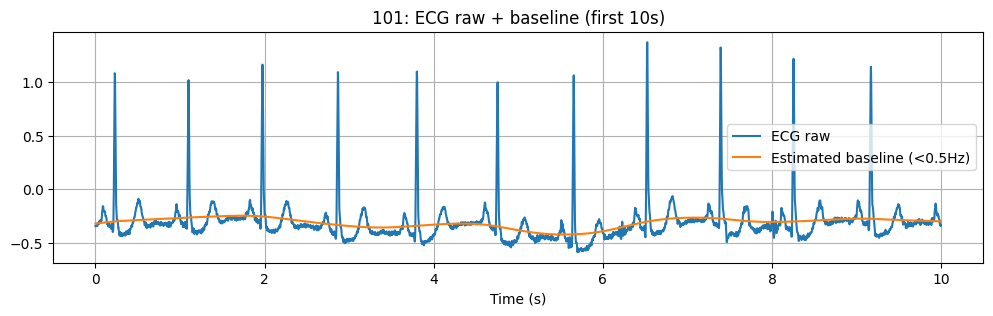

In [8]:
# Vẽ ECG raw + baseline
def plot_ecg_with_baseline(ecg_raw, baseline, fs, seconds=10, title="ECG raw + baseline"):
    n = min(int(seconds * fs), len(ecg_raw))
    t = np.arange(n) / fs
    plt.figure(figsize=(12, 3))
    plt.plot(t, ecg_raw[:n], label="ECG raw")
    plt.plot(t, baseline[:n], label="Estimated baseline (<0.5Hz)")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_ecg_with_baseline(ecg_raw, sig_qc["baseline_series"], fs, seconds=seconds_plot,
                       title=f"{rec_id}: ECG raw + baseline (first {seconds_plot}s)")

<Axes: title={'center': 'PSD (Welch) with 60 Hz harmonics'}, xlabel='Frequency (Hz)', ylabel='PSD (dB/Hz)'>

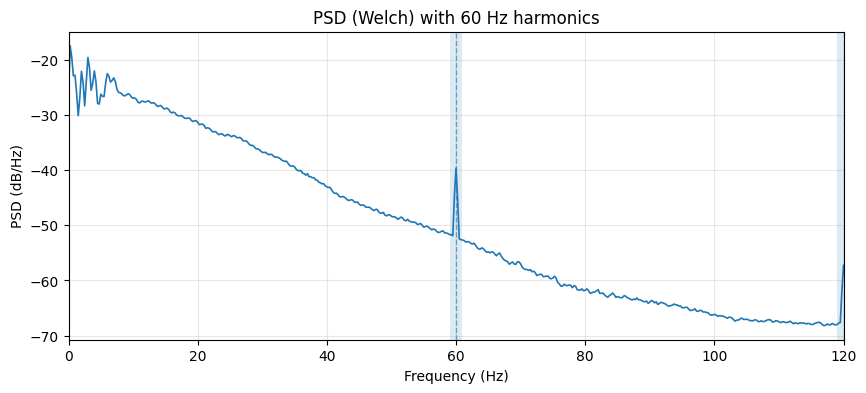

In [9]:
# Vẽ PSD với harmonics 60Hz
def plot_psd_welch_with_60_harmonics(
    x, fs,
    nperseg=None, noverlap=None, window="hann",
    fmax=360,
    harmonic_base=60,
    band_halfwidth=1.0,
    use_db=True,
    ax=None,
    title="PSD (Welch) with 60 Hz harmonics"
):
    """Vẽ PSD với tô dải quanh bội số 60Hz"""
    x = np.asarray(x).astype(float)
    x = x - np.nanmean(x)

    if nperseg is None:
        nperseg = min(len(x), int(fs * 4))
    if noverlap is None:
        noverlap = nperseg // 2

    f, pxx = welch(x, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, detrend="constant")

    fmax_eff = min(float(fmax), fs / 2.0)
    mask = (f >= 0) & (f <= fmax_eff)
    f_plot = f[mask]
    p_plot = pxx[mask]

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    if use_db:
        y = 10 * np.log10(p_plot + 1e-20)
        ax.plot(f_plot, y, linewidth=1.2)
        ax.set_ylabel("PSD (dB/Hz)")
    else:
        ax.semilogy(f_plot, p_plot, linewidth=1.2)
        ax.set_ylabel("PSD (V²/Hz)")

    ax.set_xlabel("Frequency (Hz)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    # Tô dải quanh bội số 60Hz
    harmonics = np.arange(harmonic_base, fmax_eff + 1e-9, harmonic_base)
    for h in harmonics:
        left = max(0.0, h - band_halfwidth)
        right = min(fmax_eff, h + band_halfwidth)
        ax.axvspan(left, right, alpha=0.15)
        ax.axvline(h, linestyle="--", linewidth=1.0, alpha=0.6)

    ax.set_xlim(0, fmax_eff)
    return ax

plot_psd_welch_with_60_harmonics(ecg_raw, fs=fs, band_halfwidth=1.0, fmax=120)

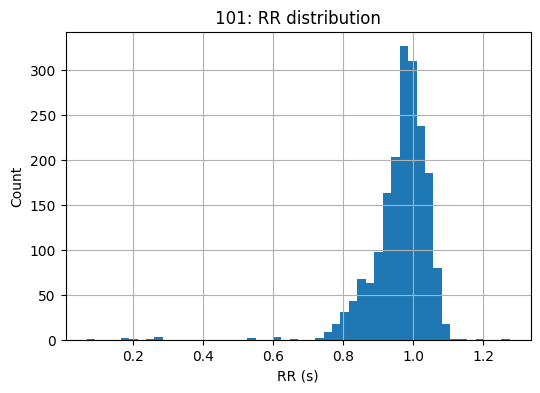

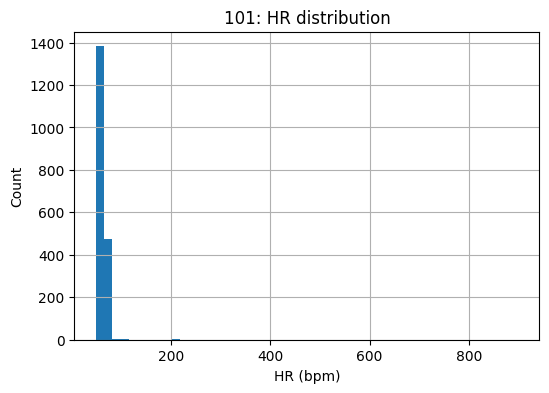

In [10]:
# Vẽ RR/HR distribution
def plot_rr_hist(rr, title="RR distribution"):
    plt.figure(figsize=(6, 4))
    plt.hist(rr, bins=50)
    plt.title(title)
    plt.xlabel("RR (s)")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

def plot_hr_hist(rr, title="HR distribution"):
    if len(rr) == 0:
        print("No RR intervals to plot HR.")
        return
    hr = 60.0 / (rr + 1e-12)
    plt.figure(figsize=(6, 4))
    plt.hist(hr, bins=50)
    plt.title(title)
    plt.xlabel("HR (bpm)")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

plot_rr_hist(rr_qc["rr"], title=f"{rec_id}: RR distribution")
plot_hr_hist(rr_qc["rr"], title=f"{rec_id}: HR distribution")

## 4. Filtering Demonstration (Baseline Removal, Notch, Bandpass)

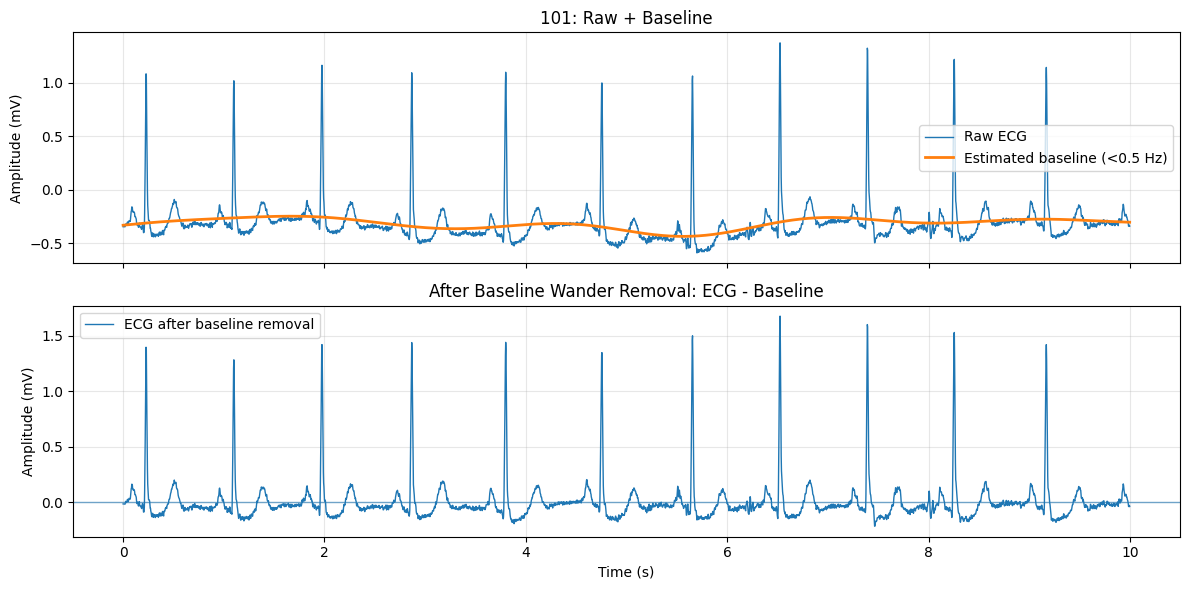

In [11]:
# Hàm loại bỏ baseline wander
def lowpass_baseline(x, fs, cutoff=0.5, order=4):
    """Ước lượng baseline bằng low-pass Butterworth"""
    x = np.asarray(x, dtype=float)
    nyq = fs / 2.0
    wn = cutoff / nyq
    b, a = butter(order, wn, btype="low")
    return filtfilt(b, a, x)

def remove_baseline_wander(ecg, fs, cutoff=0.5, order=4):
    """Loại bỏ baseline wander"""
    baseline = lowpass_baseline(ecg, fs, cutoff=cutoff, order=order)
    ecg_detrend = ecg - baseline
    return baseline, ecg_detrend

# Demo: loại bỏ baseline
baseline, ecg_detrend = remove_baseline_wander(ecg_raw, fs, cutoff=0.5, order=4)

# Vẽ so sánh
start_s, dur_s = 0, 10
i0 = int(start_s * fs)
i1 = min(len(ecg_raw), i0 + int(dur_s * fs))
t = np.arange(i0, i1) / fs

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axs[0].plot(t, ecg_raw[i0:i1], linewidth=1.0, label="Raw ECG")
axs[0].plot(t, baseline[i0:i1], linewidth=2.0, label="Estimated baseline (<0.5 Hz)")
axs[0].set_title(f"{rec_id}: Raw + Baseline")
axs[0].set_ylabel("Amplitude (mV)")
axs[0].grid(True, alpha=0.3)
axs[0].legend()

axs[1].plot(t, ecg_detrend[i0:i1], linewidth=1.0, label="ECG after baseline removal")
axs[1].axhline(0, linewidth=1.0, alpha=0.6)
axs[1].set_title("After Baseline Wander Removal: ECG - Baseline")
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Amplitude (mV)")
axs[1].grid(True, alpha=0.3)
axs[1].legend()

plt.tight_layout()
plt.show()

Detected mains: 60 Hz


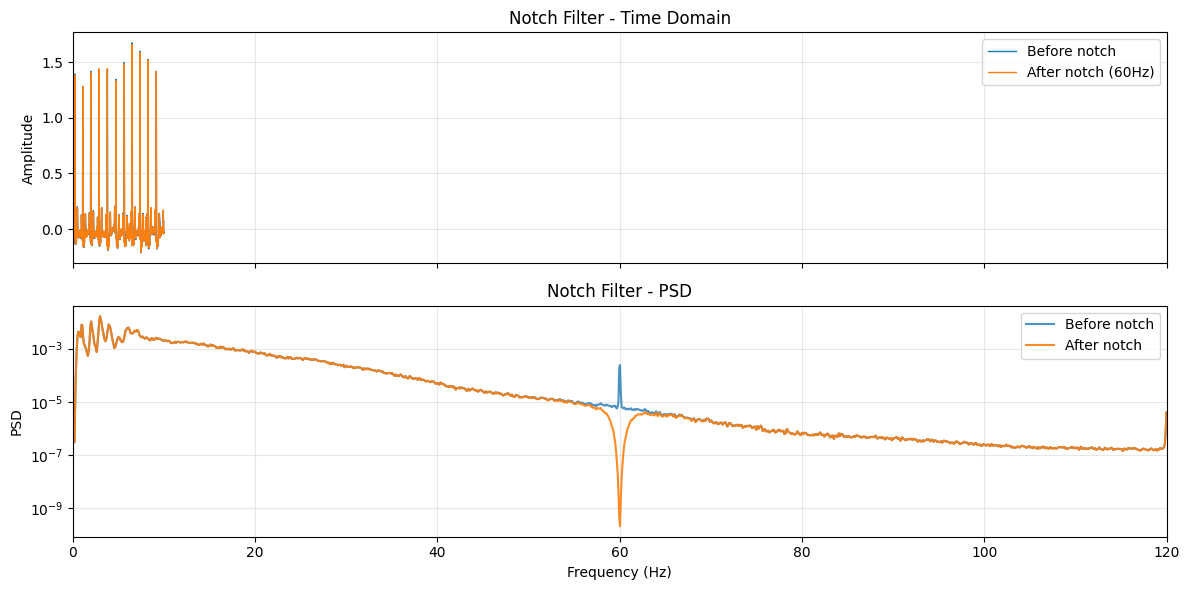

In [12]:
# Hàm notch filter
def detect_mains_from_psd(x, fs):
    """Chọn 50 hay 60Hz dựa trên peak PSD"""
    nper = min(4096, len(x))
    f, P = welch(x, fs=fs, nperseg=nper)

    def peak_near(target, bw=1.0):
        m = (f >= target - bw) & (f <= target + bw)
        return float(np.max(P[m])) if np.any(m) else 0.0

    p50 = peak_near(50.0, 1.0)
    p60 = peak_near(60.0, 1.0)
    return 50.0 if p50 >= p60 else 60.0

def notch_filter(x, fs, f0=50.0, Q=30):
    """Notch filter để loại bỏ powerline"""
    b, a = iirnotch(w0=f0, Q=Q, fs=fs)
    return filtfilt(b, a, x)

# Demo: detect mains + notch filter
mains = detect_mains_from_psd(ecg_detrend, fs)
print(f"Detected mains: {mains:.0f} Hz")

x_notched = notch_filter(ecg_detrend, fs, f0=mains, Q=30)

# Vẽ so sánh
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axs[0].plot(t, ecg_detrend[i0:i1], linewidth=1.0, label="Before notch")
axs[0].plot(t, x_notched[i0:i1], linewidth=1.0, label=f"After notch ({mains:.0f}Hz)")
axs[0].set_title(f"Notch Filter - Time Domain")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True, alpha=0.3)
axs[0].legend()

# PSD comparison
nper = min(4096, len(ecg_detrend))
f1, P1 = welch(ecg_detrend, fs=fs, nperseg=nper)
f2, P2 = welch(x_notched, fs=fs, nperseg=nper)
axs[1].semilogy(f1, P1, label="Before notch", alpha=0.8)
axs[1].semilogy(f2, P2, label="After notch", alpha=0.9)
axs[1].set_xlim(0, 120)
axs[1].set_title(f"Notch Filter - PSD")
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_ylabel("PSD")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

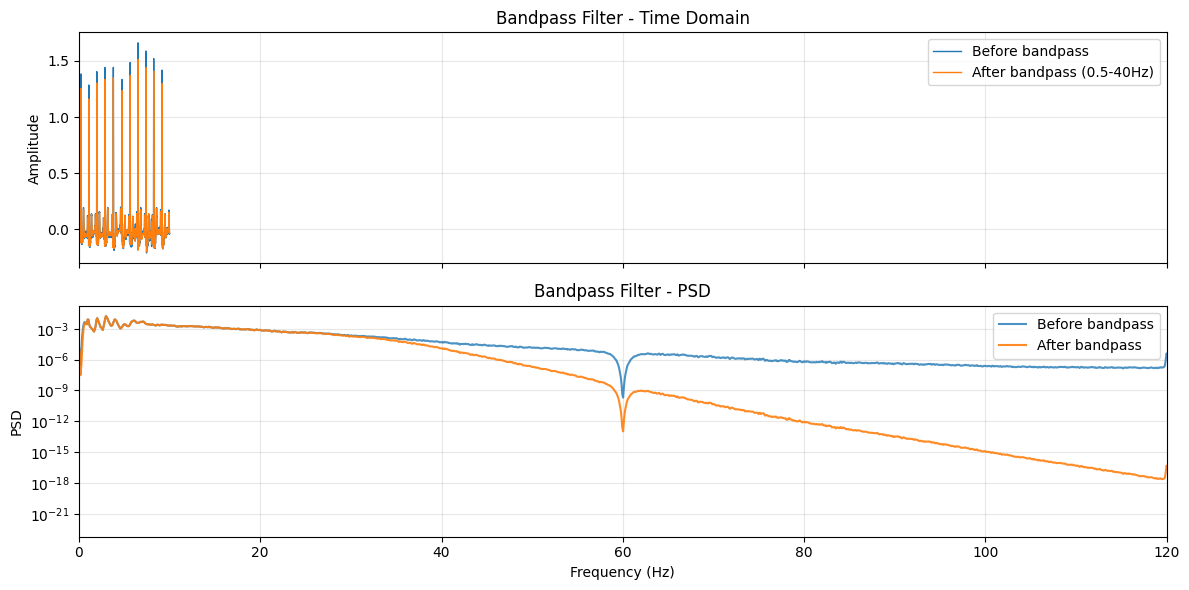

In [13]:
# Bandpass filter 0.5-40Hz
def bandpass_05_40(x, fs, order=4):
    b, a = butter(order, [0.5, 40.0], btype="bandpass", fs=fs)
    return filtfilt(b, a, x)

x_bandpassed = bandpass_05_40(x_notched, fs, order=4)

# Vẽ so sánh
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axs[0].plot(t, x_notched[i0:i1], linewidth=1.0, label="Before bandpass")
axs[0].plot(t, x_bandpassed[i0:i1], linewidth=1.0, label="After bandpass (0.5-40Hz)")
axs[0].set_title(f"Bandpass Filter - Time Domain")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True, alpha=0.3)
axs[0].legend()

# PSD comparison
f1, P1 = welch(x_notched, fs=fs, nperseg=nper)
f2, P2 = welch(x_bandpassed, fs=fs, nperseg=nper)
axs[1].semilogy(f1, P1, label="Before bandpass", alpha=0.8)
axs[1].semilogy(f2, P2, label="After bandpass", alpha=0.9)
axs[1].set_xlim(0, 120)
axs[1].set_title(f"Bandpass Filter - PSD")
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_ylabel("PSD")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

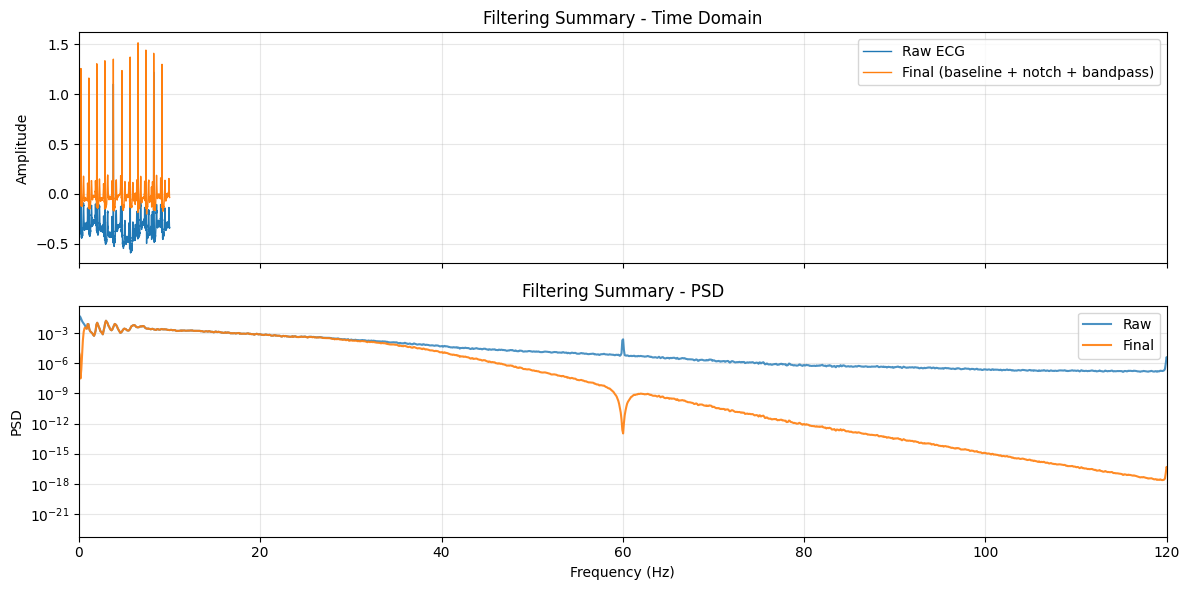

In [14]:
# Tổng kết: RAW vs FINAL (baseline + notch + bandpass)
x_final = x_bandpassed

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axs[0].plot(t, ecg_raw[i0:i1], linewidth=1.0, label="Raw ECG")
axs[0].plot(t, x_final[i0:i1], linewidth=1.0, label="Final (baseline + notch + bandpass)")
axs[0].set_title(f"Filtering Summary - Time Domain")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True, alpha=0.3)
axs[0].legend()

# PSD comparison
f1, P1 = welch(ecg_raw, fs=fs, nperseg=nper)
f2, P2 = welch(x_final, fs=fs, nperseg=nper)
axs[1].semilogy(f1, P1, label="Raw", alpha=0.8)
axs[1].semilogy(f2, P2, label="Final", alpha=0.9)
axs[1].set_xlim(0, 120)
axs[1].set_title(f"Filtering Summary - PSD")
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_ylabel("PSD")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. R-peak Detection & RR/HR Analysis

In [15]:
# Build RR & HR time series từ R-peaks
def build_rr_hr(r_locs, fs):
    """Build RR and HR from R-peak locations"""
    r_times = r_locs / fs
    rr = np.diff(r_times)
    hr = 60.0 / (rr + 1e-12)

    beat_time = r_times[1:]

    beat_df = pd.DataFrame({
        "RR_s": rr,
        "HR_bpm": hr
    }, index=beat_time)

    beat_df.index.name = "time_s"
    return beat_df

beat_df = build_rr_hr(r_peaks, fs)
print("Per-beat RR/HR:")
display(beat_df.head(10))

Per-beat RR/HR:


,RR_s,HR_bpm
time_s,,
0.230556,0.211111,284.210526
1.100000,0.869444,69.009585
1.975000,0.875000,68.571429
2.866667,0.891667,67.289720
3.800000,0.933333,64.285714
4.755556,0.955556,62.790698
5.655556,0.900000,66.666667
6.525000,0.869444,69.009585
7.394444,0.869444,69.009585


In [16]:
# Resample HR to regular grid (1Hz)
def resample_hr(beat_df, hz=1.0):
    """Resample HR to regular grid"""
    dt = 1.0 / hz
    grid = np.arange(beat_df.index.min(), beat_df.index.max(), dt)

    hr_resampled = (
        beat_df["HR_bpm"]
        .reindex(beat_df.index.union(grid))
        .sort_index()
        .interpolate(method="index")
        .reindex(grid)
    )

    return pd.DataFrame({"HR_bpm_resampled": hr_resampled.values},
                        index=pd.Index(grid, name="time_s"))

hr_1hz_df = resample_hr(beat_df, hz=1.0)
print("Resampled HR (1Hz):")
display(hr_1hz_df.head())

Resampled HR (1Hz):


,HR_bpm_resampled
time_s,
0.230556,284.210526
1.230556,68.944209
2.230556,68.204085
3.230556,66.118515
4.230556,63.612088


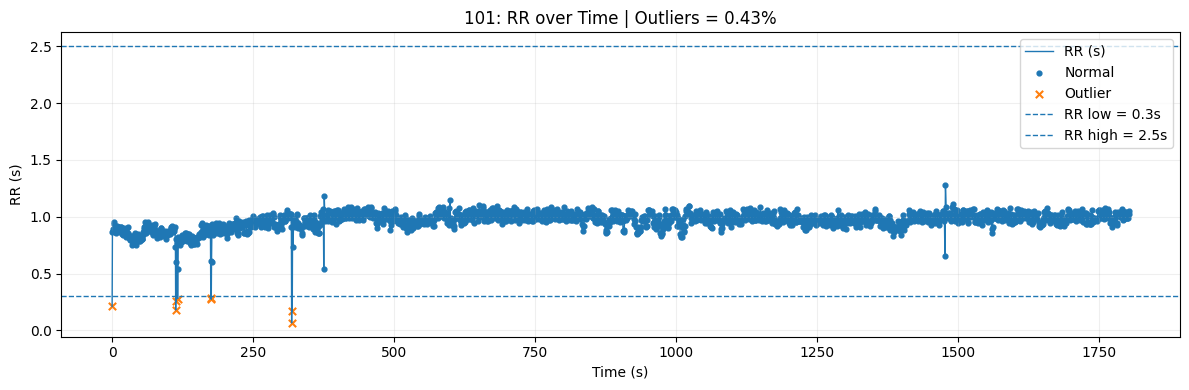

In [17]:
# Vẽ RR over time
r_times = r_peaks / fs
rr = np.diff(r_times)
t_rr = (r_times[:-1] + r_times[1:]) / 2

rr_low, rr_high = 0.3, 2.5
out_mask = (rr < rr_low) | (rr > rr_high)
bad_rr_pct = 100 * out_mask.mean() if len(rr) else 0

plt.figure(figsize=(12, 4))
plt.plot(t_rr, rr, linewidth=1, label="RR (s)")
plt.scatter(t_rr[~out_mask], rr[~out_mask], s=12, label="Normal")
plt.scatter(t_rr[out_mask], rr[out_mask], s=28, marker="x", label="Outlier")
plt.axhline(rr_low, linestyle="--", linewidth=1, label=f"RR low = {rr_low}s")
plt.axhline(rr_high, linestyle="--", linewidth=1, label=f"RR high = {rr_high}s")
plt.title(f"{rec_id}: RR over Time | Outliers = {bad_rr_pct:.2f}%")
plt.xlabel("Time (s)")
plt.ylabel("RR (s)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

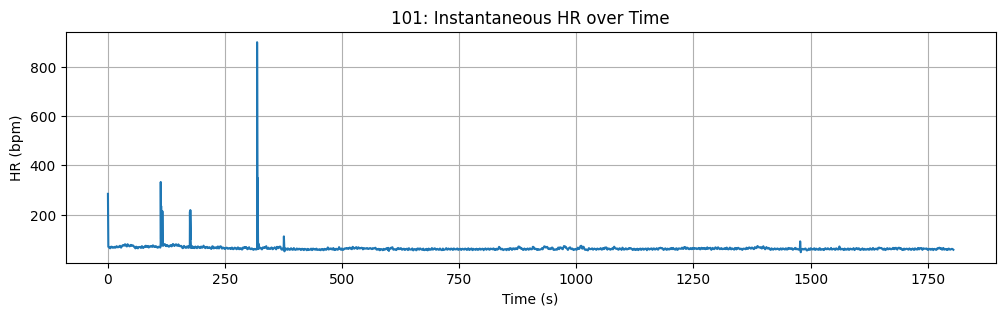

In [18]:
# Vẽ HR time series
hr_bpm = 60.0 / (rr + 1e-12)
t_beats = r_peaks[1:] / fs

plt.figure(figsize=(12, 3))
plt.plot(t_beats, hr_bpm)
plt.title(f"{rec_id}: Instantaneous HR over Time")
plt.xlabel("Time (s)")
plt.ylabel("HR (bpm)")
plt.grid(True)
plt.show()

## 6. Heart Rate Variability (HRV) Metrics

In [19]:
# Tính HRV metrics
def compute_hrv(beat_df, win=20):
    """Compute HRV metrics: RMSSD, SDNN"""
    rr = beat_df["RR_s"]

    beat_df["RMSSD_s"] = np.sqrt(
        rr.diff().pow(2).rolling(win).mean()
    )

    beat_df["SDNN_s"] = rr.rolling(win).std()

    return beat_df

beat_df = compute_hrv(beat_df, win=20)
print("HRV metrics:")
display(beat_df[["RR_s", "RMSSD_s", "SDNN_s"]].head(30))

HRV metrics:


,RR_s,RMSSD_s,SDNN_s
time_s,,,
0.230556,0.211111,NaN,NaN
1.100000,0.869444,NaN,NaN
1.975000,0.875000,NaN,NaN
2.866667,0.891667,NaN,NaN
3.800000,0.933333,NaN,NaN
4.755556,0.955556,NaN,NaN
5.655556,0.900000,NaN,NaN
6.525000,0.869444,NaN,NaN
7.394444,0.869444,NaN,NaN


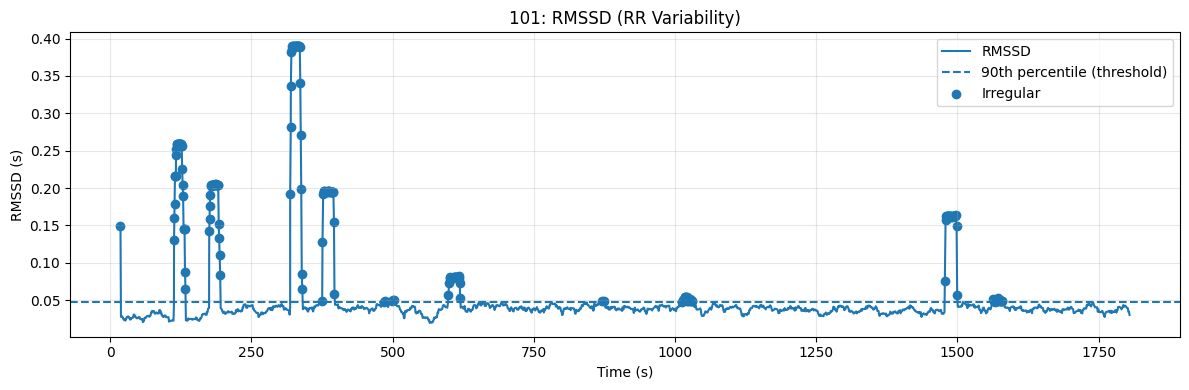

In [20]:
# Vẽ RMSSD over time
plt.figure(figsize=(12, 4))
plt.plot(beat_df.index, beat_df["RMSSD_s"], label="RMSSD")
thr = np.nanpercentile(beat_df["RMSSD_s"], 90)
plt.axhline(thr, linestyle="--", label=f"90th percentile (threshold)")
plt.scatter(beat_df.index[beat_df["RMSSD_s"] > thr],
            beat_df["RMSSD_s"][beat_df["RMSSD_s"] > thr],
            label="Irregular")
plt.title(f"{rec_id}: RMSSD (RR Variability)")
plt.xlabel("Time (s)")
plt.ylabel("RMSSD (s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. STL Decomposition of HR

In [21]:
# STL decomposition
hr_series = hr_1hz_df["HR_bpm_resampled"].astype(float)
stl = STL(hr_series, period=60, robust=True)
res = stl.fit()

decomp_df = pd.DataFrame({
    "observed": hr_series.values,
    "trend": res.trend,
    "seasonal": res.seasonal,
    "resid": res.resid
}, index=hr_1hz_df.index)
decomp_df.index.name = "time_s"

print("STL decomposition:")
display(decomp_df.head())

STL decomposition:


,observed,trend,seasonal,resid
time_s,,,,
0.230556,284.210526,74.698854,10.622185,198.889487
1.230556,68.944209,74.681856,-6.487662,0.750015
2.230556,68.204085,74.664787,-6.716495,0.255793
3.230556,66.118515,74.647642,-8.838920,0.309793
4.230556,63.612088,74.630417,-11.434272,0.415943


In [22]:
# Detect residual spikes
resid = decomp_df["resid"].astype(float)
thr = np.nanpercentile(np.abs(resid.values), 99)
flags = np.abs(resid) > thr

print(f"Detected {flags.sum()} abnormal residual spikes (>99th percentile)")

Detected 19 abnormal residual spikes (>99th percentile)


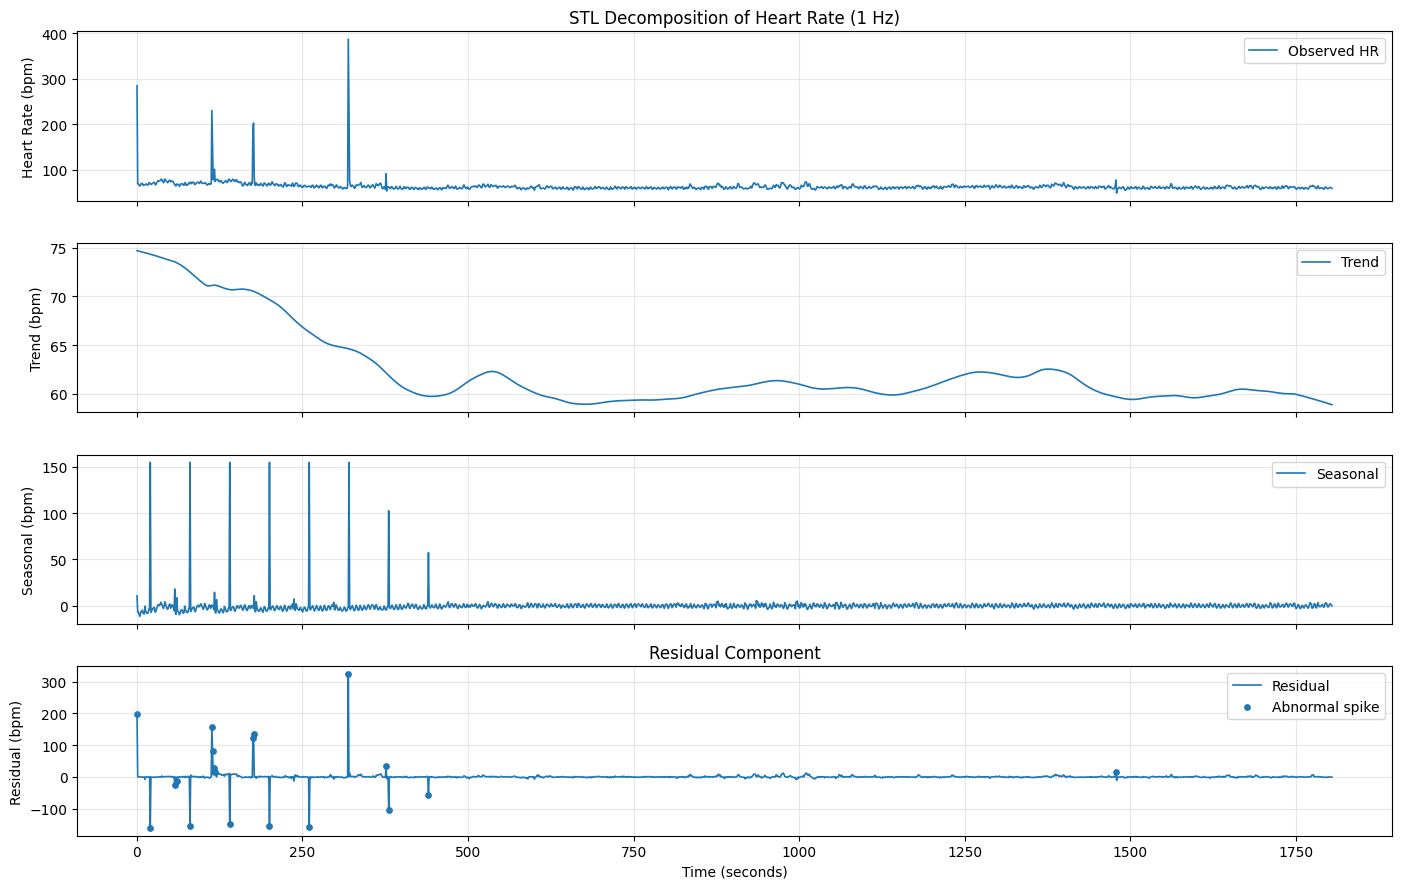

In [23]:
# Vẽ STL decomposition
t = decomp_df.index.values

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)

# Observed
axes[0].plot(t, decomp_df["observed"], linewidth=1.2, label="Observed HR")
axes[0].set_title("STL Decomposition of Heart Rate (1 Hz)")
axes[0].set_ylabel("Heart Rate (bpm)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Trend
axes[1].plot(t, decomp_df["trend"], linewidth=1.2, label="Trend")
axes[1].set_ylabel("Trend (bpm)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

# Seasonal
axes[2].plot(t, decomp_df["seasonal"], linewidth=1.2, label="Seasonal")
axes[2].set_ylabel("Seasonal (bpm)")
axes[2].legend(loc="upper right")
axes[2].grid(True, alpha=0.3)

# Residual
axes[3].plot(t, decomp_df["resid"], linewidth=1.2, label="Residual")
if flags.any():
    axes[3].scatter(t[flags.values], decomp_df["resid"][flags].values,
                   s=15, label="Abnormal spike")
axes[3].set_title("Residual Component")
axes[3].set_xlabel("Time (seconds)")
axes[3].set_ylabel("Residual (bpm)")
axes[3].legend(loc="upper right")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Abnormality Detection

In [24]:
# Detect abnormalities
def detect_abnormal(beat_df, hr_df):
    """Detect various ECG abnormalities"""
    med_rr = beat_df["RR_s"].median()

    # RR outliers
    beat_df["RR_outlier"] = (
        (beat_df["RR_s"] < 0.5 * med_rr) |
        (beat_df["RR_s"] > 1.8 * med_rr)
    )

    # Irregular (high RMSSD)
    thr = np.nanpercentile(beat_df["RMSSD_s"], 90)
    beat_df["irregular"] = beat_df["RMSSD_s"] > thr

    # PVC-like pattern
    rr = beat_df["RR_s"].values
    pvc = np.zeros(len(rr), dtype=bool)
    for i in range(len(rr)-1):
        if rr[i] < 0.8*med_rr and rr[i+1] > 1.2*med_rr:
            pvc[i] = True
    beat_df["pvc_like"] = pvc

    # HR episodes
    hr_df["tachy"] = hr_df["HR_bpm_resampled"] > 120
    hr_df["brady"] = hr_df["HR_bpm_resampled"] < 50

    return beat_df, hr_df, thr

beat_df, hr_1hz_df, rmssd_thr = detect_abnormal(beat_df, hr_1hz_df)

print(f"RR outliers: {beat_df['RR_outlier'].sum()}")
print(f"Irregular: {beat_df['irregular'].sum()}")
print(f"PVC-like: {beat_df['pvc_like'].sum()}")
print(f"Tachycardia: {hr_1hz_df['tachy'].sum()}")
print(f"Bradycardia: {hr_1hz_df['brady'].sum()}")

RR outliers: 8
Irregular: 186
PVC-like: 2
Tachycardia: 7
Bradycardia: 1


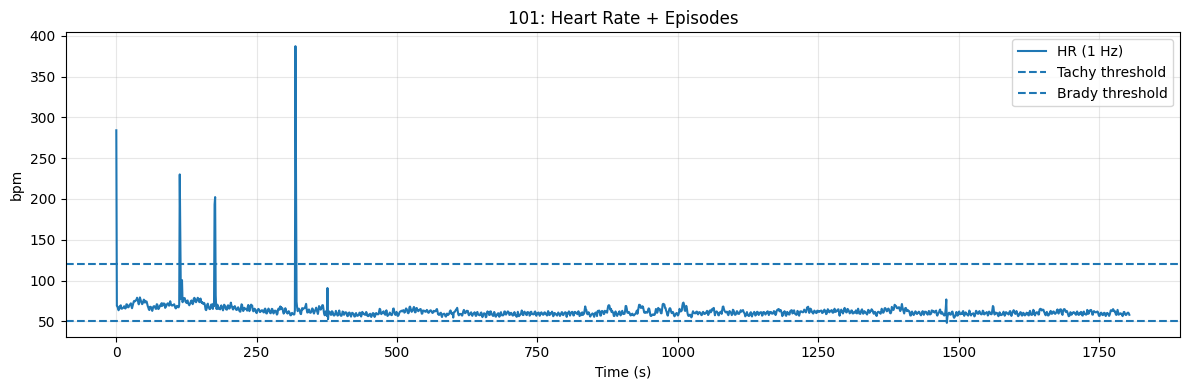

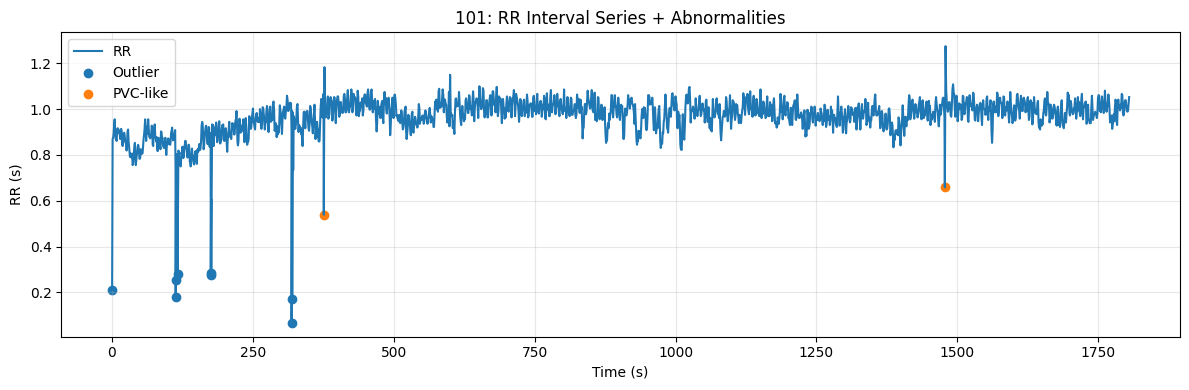

In [25]:
# Vẽ abnormality detection results
# HR + episodes
plt.figure(figsize=(12,4))
plt.plot(hr_1hz_df.index, hr_1hz_df["HR_bpm_resampled"], label="HR (1 Hz)")
plt.axhline(120, linestyle="--", label="Tachy threshold")
plt.axhline(50, linestyle="--", label="Brady threshold")
plt.title(f"{rec_id}: Heart Rate + Episodes")
plt.xlabel("Time (s)")
plt.ylabel("bpm")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# RR + abnormalities
plt.figure(figsize=(12,4))
plt.plot(beat_df.index, beat_df["RR_s"], label="RR")
plt.scatter(beat_df.index[beat_df["RR_outlier"]],
            beat_df["RR_s"][beat_df["RR_outlier"]],
            label="Outlier")
plt.scatter(beat_df.index[beat_df["pvc_like"]],
            beat_df["RR_s"][beat_df["pvc_like"]],
            label="PVC-like")
plt.title(f"{rec_id}: RR Interval Series + Abnormalities")
plt.xlabel("Time (s)")
plt.ylabel("RR (s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Label Distribution Statistics

In [26]:
# Thống kê label annotation 1xx và 2xx
def count_labels(record_list):
    """Đếm số annotation symbol từ file .atr"""
    label_counter = Counter()

    for rec in record_list:
        ann = wfdb.rdann(rec, "atr", pn_dir="mitdb")
        label_counter.update(ann.symbol)

    return label_counter

label_count_1xx = count_labels(records_1xx)
label_count_2xx = count_labels(records_2xx)

total_1xx = sum(label_count_1xx.values())
total_2xx = sum(label_count_2xx.values())

all_labels = sorted(
    set(label_count_1xx.keys()) | set(label_count_2xx.keys()),
    key=lambda x: label_count_1xx[x] + label_count_2xx[x],
    reverse=True
)

label_rows = []

for label in all_labels:
    count_1xx = label_count_1xx[label]
    count_2xx = label_count_2xx[label]
    total_count = count_1xx + count_2xx

    label_rows.append({
        "Label": label,
        "1xx Count": count_1xx,
        "1xx (%)": round(count_1xx / total_1xx * 100, 4),
        "2xx Count": count_2xx,
        "2xx (%)": round(count_2xx / total_2xx * 100, 4),
        "Total Count": total_count,
        "Total (%)": round(total_count / (total_1xx + total_2xx) * 100, 4)
    })

label_distribution_df = pd.DataFrame(label_rows)
display(label_distribution_df)

,Label,1xx Count,1xx (%),2xx Count,2xx (%),Total Count,Total (%)
0,N,31545,65.4135,43507,67.5333,75052,66.6258
1,L,4615,9.5699,3460,5.3708,8075,7.1684
2,R,3697,7.6663,3562,5.5291,7259,6.4440
3,V,1346,2.7911,5784,8.9782,7130,6.3295
4,/,5486,11.3761,1542,2.3936,7028,6.2390
5,A,155,0.3214,2391,3.7114,2546,2.2602
6,+,227,0.4707,1064,1.6516,1291,1.1461
7,f,722,1.4972,260,0.4036,982,0.8717
8,F,13,0.0270,790,1.2263,803,0.7128
9,~,278,0.5765,338,0.5247,616,0.5468
